[i] Crop Recommendation Data loaded successfully.

Data preview:
     N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

[+] Training Logistic Regression model...
Accuracy: 97.27%

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1

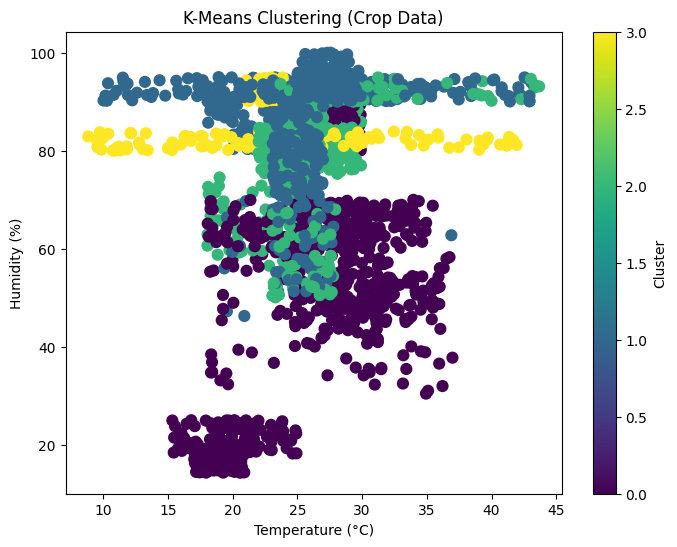

K-Means model saved successfully.


In [4]:
#  Importing Libraries

import os
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score


#  Setting path

DATA_PATH = "/content/archive (6).zip"
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)


# Laod Dataset

def load_data():
    if os.path.exists(DATA_PATH):
        df = pd.read_csv(DATA_PATH)
        print("[i] Crop Recommendation Data loaded successfully.")
    else:
        raise FileNotFoundError("Dataset not found.")
    return df


# Train Logistic Regression Model

def train_logistic_regression(df):
    print("\n[+] Training Logistic Regression model...")

     # Independent features
    X = df[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]]
   # Target column (crop label)
    y = df["label"]

    # Split data into training (80%) and testing (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Standardize numerical values
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Creat and train model
    model = LogisticRegression(max_iter=500)
    model.fit(X_train_s, y_train)

   # Save the trained model and scaler
    with open(os.path.join(MODELS_DIR, "logistic_crop_model.pkl"), "wb") as f:
        pickle.dump(model, f)
    with open(os.path.join(MODELS_DIR, "scaler_crop.pkl"), "wb") as f:
        pickle.dump(scaler, f)

   # Evaluate the model
    y_pred = model.predict(X_test_s)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc * 100:.2f}%")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Apply K-Means Clustering
def apply_kmeans(df):
    print("\n[+] Applying K-Means clustering...")

     # Select only numerical columns
    X = df[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]]

   # Standardize values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

     # Apply K-Means with 4 initial clusters
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df["Cluster"] = kmeans.fit_predict(X_scaled)

  # Calculate Silhouette Score
    score = silhouette_score(X_scaled, df["Cluster"])
    print(f"Silhouette Score: {score:.3f}")

  # Plot Clustering Results
    plt.figure(figsize=(8, 6))
    plt.scatter(df["temperature"], df["humidity"], c=df["Cluster"], cmap="viridis", s=60)
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Humidity (%)")
    plt.title("K-Means Clustering (Crop Data)")
    plt.colorbar(label="Cluster")
    plt.show()

    # Save K-Means model
    with open(os.path.join(MODELS_DIR, "kmeans_crop_model.pkl"), "wb") as f:
        pickle.dump(kmeans, f)

    print("K-Means model saved successfully.")


# Main Function
def main():
    df = load_data()
    print("\nData preview:\n", df.head())
    train_logistic_regression(df)
    apply_kmeans(df)


if __name__ == "__main__":
    main()
